In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [2]:
column_names = [
    "user_id",
    "movie_id",
    "rating",
    "timestamp"
]

train = pd.read_csv(
    "../data/u1.base",
    sep="\t",
    names=column_names
)

test = pd.read_csv(
    "../data/u1.test",
    sep="\t",
    names=column_names
)

In [5]:
train["user_id"] -= 1
train["movie_id"] -= 1

test["user_id"] -= 1
test["movie_id"] -= 1

In [7]:
num_users = max(
    train["user_id"].max(),
    test["user_id"].max()
) + 1

num_movies = max(
    train["movie_id"].max(),
    test["movie_id"].max()
) + 1

print("Users :", num_users)
print("Movies:", num_movies)

Users : 943
Movies: 1682


In [8]:
class TwoTowerDataset(Dataset):

    def __init__(self, ratings):

        self.users = torch.LongTensor(
            ratings["user_id"].values
        )

        self.movies = torch.LongTensor(
            ratings["movie_id"].values
        )

    def __len__(self):

        return len(self.users)

    def __getitem__(self, idx):

        return (

            self.users[idx],

            self.movies[idx]

        )

In [9]:
train_dataset = TwoTowerDataset(
    train
)

test_dataset = TwoTowerDataset(
    test
)

C:\Users\miyas\AppData\Local\Temp\ipykernel_5728\3990556388.py:5: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  self.users = torch.LongTensor(


In [10]:
train_loader = DataLoader(

    train_dataset,

    batch_size=256,

    shuffle=True

)

test_loader = DataLoader(

    test_dataset,

    batch_size=256,

    shuffle=False

)

In [11]:
users, movies = next(
    iter(train_loader)
)

print(users.shape)
print(movies.shape)

torch.Size([256])
torch.Size([256])


In [12]:
class UserTower(nn.Module):

    def __init__(
        self,
        num_users,
        embedding_dim=32
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            num_users,
            embedding_dim
        )

        self.network = nn.Sequential(

            nn.Linear(
                embedding_dim,
                64
            ),

            nn.ReLU(),

            nn.Linear(
                64,
                embedding_dim
            )

        )

    def forward(
        self,
        users
    ):

        x = self.embedding(
            users
        )

        x = self.network(
            x
        )

        return x

In [13]:
class MovieTower(nn.Module):

    def __init__(
        self,
        num_movies,
        embedding_dim=32
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            num_movies,
            embedding_dim
        )

        self.network = nn.Sequential(

            nn.Linear(
                embedding_dim,
                64
            ),

            nn.ReLU(),

            nn.Linear(
                64,
                embedding_dim
            )

        )

    def forward(
        self,
        movies
    ):

        x = self.embedding(
            movies
        )

        x = self.network(
            x
        )

        return x

In [14]:
class TwoTowerModel(nn.Module):

    def __init__(
        self,
        num_users,
        num_movies,
        embedding_dim=32
    ):

        super().__init__()

        self.user_tower = UserTower(
            num_users,
            embedding_dim
        )

        self.movie_tower = MovieTower(
            num_movies,
            embedding_dim
        )

    def forward(
        self,
        users,
        movies
    ):

        user_embedding = self.user_tower(
            users
        )

        movie_embedding = self.movie_tower(
            movies
        )

        return (

            user_embedding,

            movie_embedding

        )

In [15]:
model = TwoTowerModel(

    num_users,

    num_movies,

    embedding_dim=32

)

model

TwoTowerModel(
  (user_tower): UserTower(
    (embedding): Embedding(943, 32)
    (network): Sequential(
      (0): Linear(in_features=32, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=32, bias=True)
    )
  )
  (movie_tower): MovieTower(
    (embedding): Embedding(1682, 32)
    (network): Sequential(
      (0): Linear(in_features=32, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=32, bias=True)
    )
  )
)

In [16]:
users, movies = next(
    iter(train_loader)
)

user_embedding, movie_embedding = model(

    users,

    movies

)

print(user_embedding.shape)

print(movie_embedding.shape)

torch.Size([256, 32])
torch.Size([256, 32])


In [17]:
print(user_embedding[:3])

print()

print(movie_embedding[:3])

tensor([[-0.0749, -0.1818, -0.2136,  0.0825,  0.4200,  0.2872,  0.1092,  0.1524,
          0.2962, -0.5360,  0.1660, -0.4060, -0.1607,  0.0108,  0.0778, -0.3611,
          0.3414,  0.0695, -0.0535, -0.0288,  0.7117, -0.0536, -0.2823,  0.3712,
         -0.1995,  0.0247, -0.1668,  0.3991, -0.0029,  0.4028, -0.5857, -0.0788],
        [ 0.0805,  0.1118, -0.0671, -0.1211, -0.4354,  0.2285, -0.2294,  0.2927,
         -0.0890, -0.2829,  0.1589,  0.3383, -0.1004,  0.0623, -0.0782, -0.2805,
          0.2020, -0.0601,  0.1699, -0.0196,  0.5634, -0.0457,  0.6482, -0.0460,
          0.5938, -0.0552,  0.2738,  0.1939,  0.1743, -0.0189, -0.4149, -0.0157],
        [-0.9698, -0.4921,  0.0329, -0.4987, -0.1105, -0.1022,  0.3982,  0.0613,
          0.4915, -0.4674,  0.0169, -0.1740,  0.0989,  0.1975,  0.3159,  0.3374,
          0.2107, -0.2906, -0.3951, -0.0262,  0.4614,  0.3599,  0.3757,  0.3949,
         -0.1141, -0.0968, -0.3417,  0.0661, -0.1096,  0.3439, -0.2150, -0.1922]],
       grad_fn=<SliceBac

In [18]:
users, movies = next(iter(train_loader))

user_embedding, movie_embedding = model(
    users,
    movies
)

similarity = torch.matmul(
    user_embedding,
    movie_embedding.T
)

print(similarity.shape)

torch.Size([256, 256])


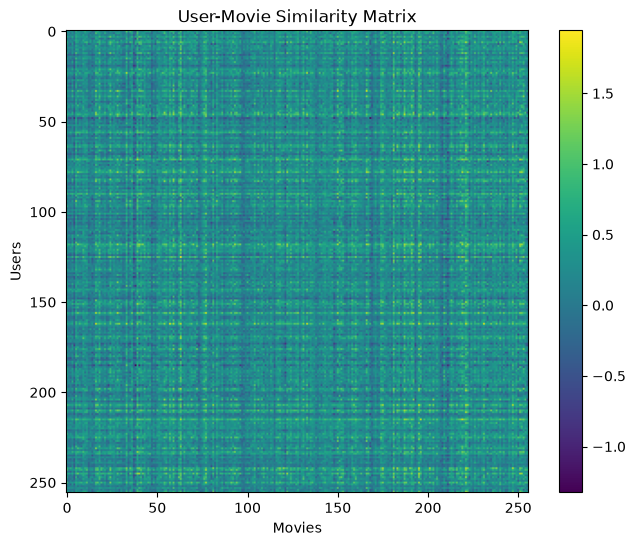

In [21]:
plt.figure(figsize=(8,6))

plt.imshow(
    similarity.detach().numpy(),
    cmap="viridis"
)

plt.colorbar()

plt.title("User-Movie Similarity Matrix")

plt.xlabel("Movies")

plt.ylabel("Users")

plt.show()

In [24]:
labels = torch.arange(
    similarity.size(0)
)
labels

tensor([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,
         28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,
         42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,
         56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,
         70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,
         84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,
         98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111,
        112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125,
        126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139,
        140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153,
        154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167,
        168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 1

In [26]:
criterion = nn.CrossEntropyLoss()

loss = criterion(
    similarity,
    labels
)
loss

tensor(5.6024, grad_fn=<NllLossBackward0>)

In [27]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

In [28]:
def train(
    model,
    train_loader,
    optimizer,
    epochs=20
):

    criterion = nn.CrossEntropyLoss()

    print("Training Two-Tower Retrieval Model...")

    for epoch in range(epochs):

        model.train()

        total_loss = 0.0

        for users, movies in train_loader:

            optimizer.zero_grad()

            user_embedding, movie_embedding = model(
                users,
                movies
            )

            similarity = torch.matmul(
                user_embedding,
                movie_embedding.T
            )

            labels = torch.arange(
                similarity.size(0)
            )

            loss = criterion(
                similarity,
                labels
            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        average_loss = (
            total_loss /
            len(train_loader)
        )

        print(
            f"Epoch {epoch+1:2d}/{epochs}"
            f" | Loss = {average_loss:.4f}"
        )

In [30]:
train(
    model,
    train_loader,
    optimizer,
    epochs=20
)

Training Two-Tower Retrieval Model...
Epoch  1/20 | Loss = 5.0569
Epoch  2/20 | Loss = 5.0496
Epoch  3/20 | Loss = 5.0437
Epoch  4/20 | Loss = 5.0370
Epoch  5/20 | Loss = 5.0305
Epoch  6/20 | Loss = 5.0256
Epoch  7/20 | Loss = 5.0198
Epoch  8/20 | Loss = 5.0157
Epoch  9/20 | Loss = 5.0100
Epoch 10/20 | Loss = 5.0055
Epoch 11/20 | Loss = 5.0011
Epoch 12/20 | Loss = 4.9975
Epoch 13/20 | Loss = 4.9925
Epoch 14/20 | Loss = 4.9885
Epoch 15/20 | Loss = 4.9854
Epoch 16/20 | Loss = 4.9815
Epoch 17/20 | Loss = 4.9778
Epoch 18/20 | Loss = 4.9738
Epoch 19/20 | Loss = 4.9713
Epoch 20/20 | Loss = 4.9666


In [31]:
model.eval()

with torch.no_grad():

    movie_ids = torch.arange(
        num_movies
    )

    movie_embeddings = model.movie_tower(
        movie_ids
    )

print(movie_embeddings.shape)

torch.Size([1682, 32])


In [32]:
with torch.no_grad():

    user_embedding = model.user_tower(

        torch.tensor([0])

    )

print(user_embedding.shape)

torch.Size([1, 32])


In [33]:
similarities = torch.matmul(

    user_embedding,

    movie_embeddings.T

)

print(similarities.shape)

torch.Size([1, 1682])


In [34]:
top_scores, top_indices = torch.topk(

    similarities,

    k=10

)

print(top_indices)

print()

print(top_scores)

tensor([[1502,  952,   15,  105, 1014,   29,   74, 1092,  118, 1618]])

tensor([[2.0932, 2.0841, 1.9311, 1.7943, 1.7833, 1.7423, 1.7268, 1.7022, 1.6830,
         1.6085]])


In [35]:
movie_columns = [

    "movie_id",

    "title",

    "release_date",

    "video_release_date",

    "IMDb_URL"

]

genre_names = [

    "unknown",

    "Action",

    "Adventure",

    "Animation",

    "Children",

    "Comedy",

    "Crime",

    "Documentary",

    "Drama",

    "Fantasy",

    "Film-Noir",

    "Horror",

    "Musical",

    "Mystery",

    "Romance",

    "Sci-Fi",

    "Thriller",

    "War",

    "Western"

]

movie_columns += genre_names

movies = pd.read_csv(

    "../data/u.item",

    sep="|",

    encoding="latin-1",

    names=movie_columns

)

In [36]:
recommended_movies = movies.loc[

    top_indices.squeeze().numpy()

]

recommended_movies[
    [
        "movie_id",
        "title"
    ]
]

,movie_id,title
1502,1503,Gold Diggers: The Secret of Bear Mountain (1995)
952,953,Unstrung Heroes (1995)
15,16,French Twist (Gazon maudit) (1995)
105,106,Diabolique (1996)
1014,1015,Shiloh (1997)
29,30,Belle de jour (1967)
74,75,Brother Minister: The Assassination of Malcolm...
1092,1093,Live Nude Girls (1995)
118,119,Maya Lin: A Strong Clear Vision (1994)
1618,1619,All Things Fair (1996)


In [37]:
import faiss

In [39]:
movie_vectors = movie_embeddings.numpy().astype(
    np.float32
)

In [42]:
dimension = movie_vectors.shape[1]

print(dimension)

32


In [ ]:
index = faiss.IndexFlatIP(
    dimension
)

<faiss.swigfaiss.IndexFlatIP; proxy of <Swig Object of type 'faiss::IndexFlatIP *' at 0x000002122313A730> >

In [44]:
index.add(
    movie_vectors
)

print(index.ntotal)

1682


In [46]:
query = user_embedding.numpy().astype(
    np.float32
)
query

array([[-0.431667  , -0.42719197, -0.63554174,  1.0494334 , -0.18146457,
        -0.12174219, -0.00135036,  0.56740844, -0.29238597, -0.6876341 ,
         0.22306952, -0.27001727, -0.04136284, -0.51306623, -0.3673299 ,
         0.19692051, -0.4544239 ,  0.23501311, -0.17087948,  0.10985668,
        -0.23582648, -0.1916083 ,  0.20314085, -0.39591336,  0.02318248,
         0.17978501,  0.43128574,  0.29553038, -0.36278403, -0.2712393 ,
        -0.03129598, -0.03342646]], dtype=float32)

In [49]:
scores, indices = index.search(

    query,

    k=10

)
print(scores)
print(indices)

[[2.0931554 2.0841012 1.931107  1.7943118 1.7832553 1.7423365 1.7267784
  1.702244  1.6830385 1.6085203]]
[[1502  952   15  105 1014   29   74 1092  118 1618]]


In [50]:
recommended = movies.iloc[
    indices[0]
][
    [
        "movie_id",
        "title"
    ]
]

recommended

,movie_id,title
1502,1503,Gold Diggers: The Secret of Bear Mountain (1995)
952,953,Unstrung Heroes (1995)
15,16,French Twist (Gazon maudit) (1995)
105,106,Diabolique (1996)
1014,1015,Shiloh (1997)
29,30,Belle de jour (1967)
74,75,Brother Minister: The Assassination of Malcolm...
1092,1093,Live Nude Girls (1995)
118,119,Maya Lin: A Strong Clear Vision (1994)
1618,1619,All Things Fair (1996)
